In [1]:
import yfinance as yf
import numpy as np

In [10]:
tickers = [
                'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'V', 'TSLA', 'UNH',
                'HD', 'BAC', 'MA', 'XOM', 'PFE', 'KO', 'MRK', 'PEP', 'WMT', 'CVX',
                'ABT', 'TMO', 'CSCO', 'COST', 'DIS', 'INTC', 'LLY', 'QCOM', 'ADBE', 'CRM'
            ]
df = yf.download(tickers, start="2018-01-01", end="2023-12-31")['Close'].dropna()
prices = df.values
if prices.shape[1] > 30:
    prices = prices[:, :30]

np.savetxt("prices.csv", prices, delimiter=",")
print("Saved prices.csv with shape:", prices.shape)

C:\Users\inula\AppData\Local\Temp\ipykernel_28216\1618266369.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2018-01-01", end="2023-12-31")['Close'].dropna()
[*********************100%***********************]  30 of 30 completed


Saved prices.csv with shape: (1509, 30)


In [1]:
import seaborn as sns

In [30]:
pastel_palette = sns.color_palette([
    "#7b68ee",  # medium slate blue
    "#ffb6c1",  # light pink
    "#87cefa",  # light sky blue
    "#90ee90",  # light green
    "#ffa07a"   # light salmon
])

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette=pastel_palette,
    font="sans-serif",
    rc={
        "font.sans-serif": ["Nunito", "Quicksand", "Comic Neue", "DejaVu Sans"],
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 10,
        "axes.linewidth": 1.5,
        "grid.linewidth": 0.8,
        "grid.color": "#dcdcdc",
        "grid.alpha": 0.6,
        "lines.linewidth": 2.5,
        "lines.markersize": 0,   # effectively no markers
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "text.color": "#333333",
        "axes.labelcolor": "#333333",
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.facecolor": "#f7f7f7",
        "legend.edgecolor": "#cccccc"
    }
)


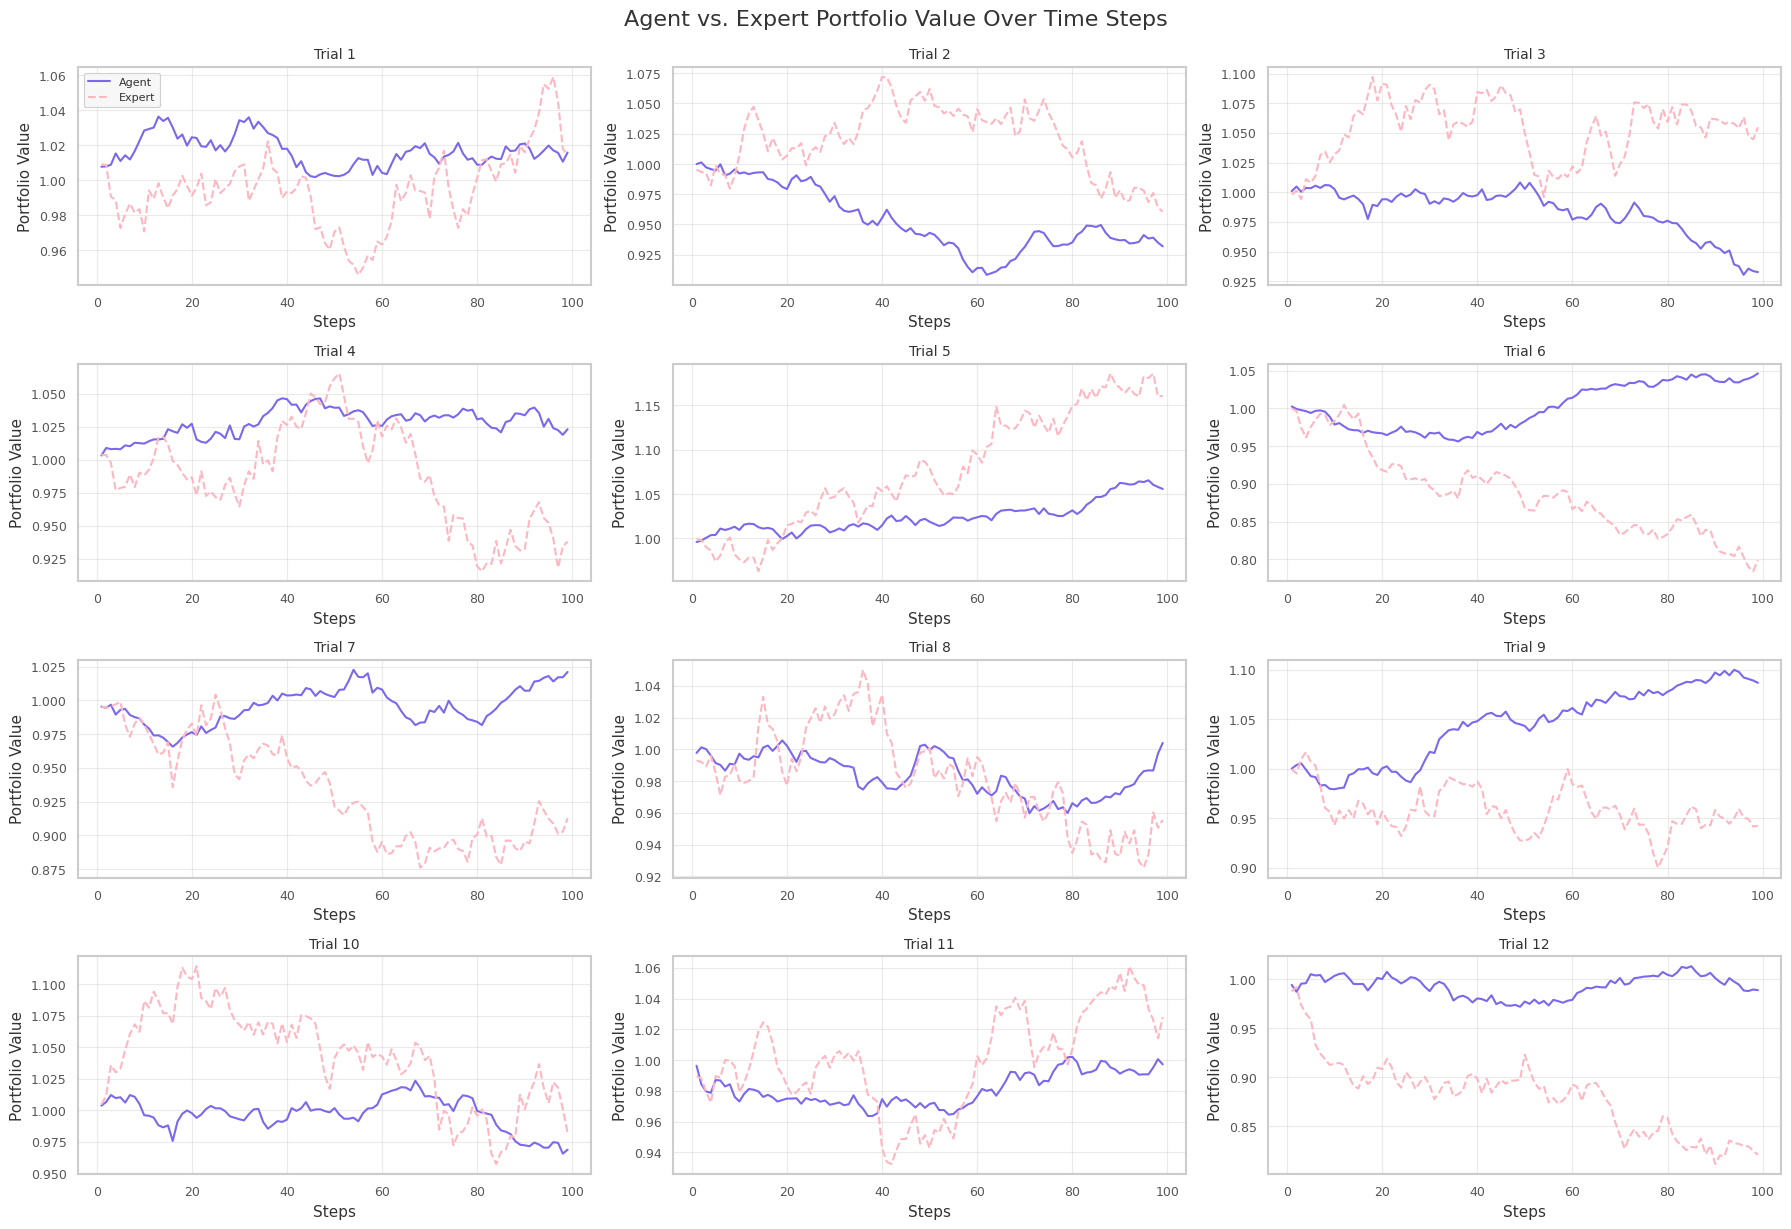

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Define path to the logs
log_dir = r"C:\Users\inula\OneDrive\ドキュメント\GitHub\GDMOPT\log\data\bl_yf"

# Get all CSV file paths
paths = sorted([
    os.path.join(log_dir, f)
    for f in os.listdir(log_dir)
    if f.endswith(".csv")
])

# Setup figure for 3 columns × 4 rows
n = len(paths)
rows, cols = 4, 3
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
axs = axs.flatten()

for i, path in enumerate(paths):
    df = pd.read_csv(path)
    df["returns"] = df["returns"].apply(eval)
    df["expert_action"] = df["sub_expert_action"].apply(eval)
    df["expert_return"] = df.apply(lambda row: np.dot(row["expert_action"], row["returns"]), axis=1)

    # Compute cumulative expert portfolio values
    expert_portfolio = [1.0]
    for r in df["expert_return"]:
        expert_portfolio.append(expert_portfolio[-1] * (1 + r))
    df["expert_portfolio_value"] = expert_portfolio[1:]

    # Plot in subplot
    ax = axs[i]
    ax.plot(df["step"], df["portfolio_value"], label="Agent", linewidth=1.5)
    ax.plot(df["step"], df["expert_portfolio_value"], label="Expert", linestyle="--", linewidth=1.5)
    ax.set_title(f"Trial {i+1}", fontsize=10)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Portfolio Value")
    ax.grid(True)

    if i == 0:
        ax.legend(fontsize=8)

# Hide unused subplots
for j in range(n, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Agent vs. Expert Portfolio Value Over Time Steps", fontsize=16, y=1.02)
plt.show()


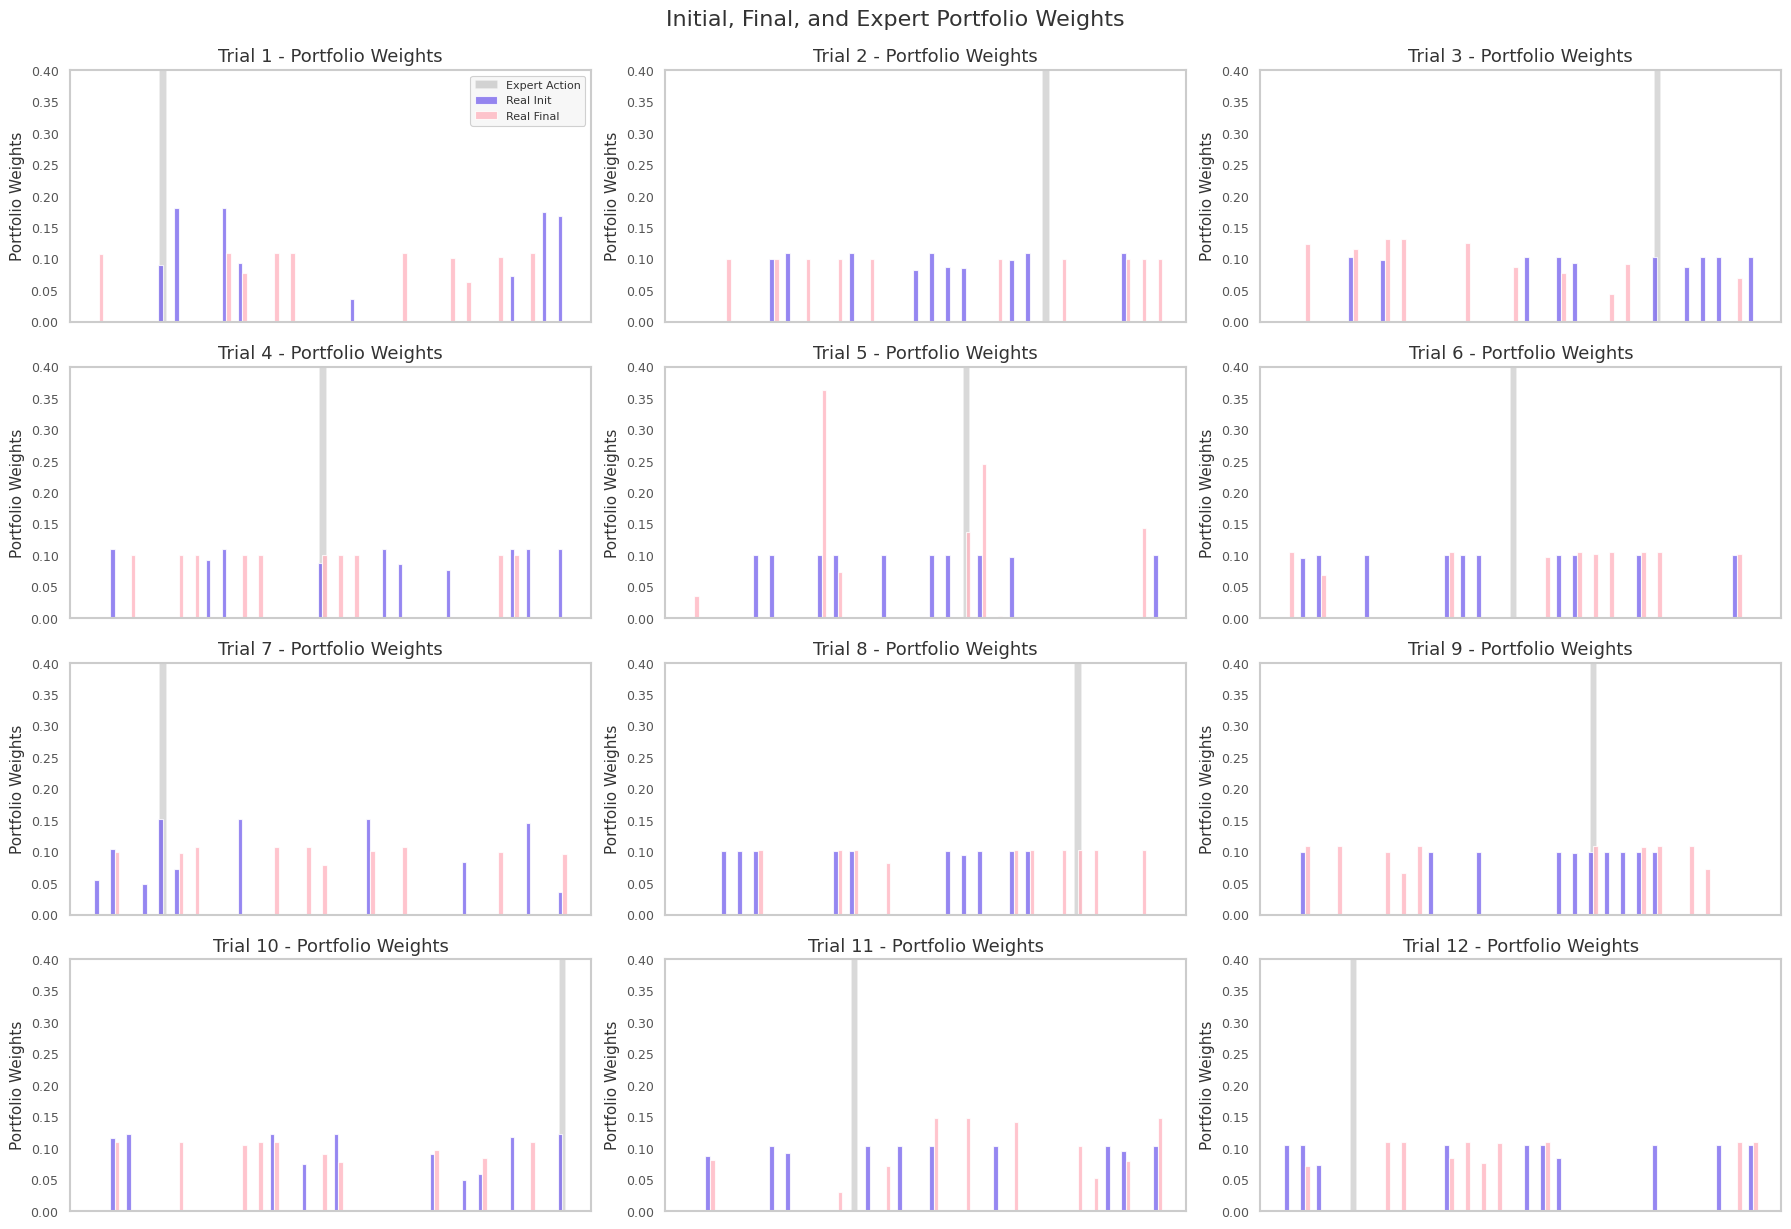

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_assets = 30  # Number of assets
rows, cols = 4, 3
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
axs = axs.flatten()

bar_width = 0.3
x = np.arange(n_assets)

for i, path in enumerate(paths):
    df = pd.read_csv(path)
    df["real_action"] = df["real_action"].apply(eval)
    df["expert_action"] = df["expert_action"].apply(eval)  # load expert_action too

    real_init = np.array(df["real_action"].iloc[0])
    real_final = np.array(df["real_action"].iloc[-1])
    expert_action = np.array(df["expert_action"].iloc[-1])

    ax = axs[i]
    # Expert bars - wider and transparent black (behind)
    ax.bar(x, expert_action, bar_width * 1.3, color='black', alpha=0.15, label='Expert Action')

    # Real init/final bars on top with offset
    ax.bar(x - bar_width/2, real_init, bar_width, label='Real Init', alpha=0.8)
    ax.bar(x + bar_width/2, real_final, bar_width, label='Real Final', alpha=0.8)

    ax.set_xticks([])
    ax.set_ylim(0, 0.4)
    ax.set_title(f"Trial {i+1} - Portfolio Weights")
    ax.set_ylabel("Portfolio Weights")
    ax.grid(axis='y')

    if i == 0:
        ax.legend(fontsize=8)

# Remove unused subplots if any
for j in range(len(paths), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Initial, Final, and Expert Portfolio Weights", fontsize=16, y=1.02)
plt.show()
